# M2 — Model 2 of 4: ResNet-18 (deep network with skip connections)

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I
**Dataset:** Jannat, Preety & Mojumdar (2024), *Dataset of Medicinal Plant Leaves:
Hibiscus, Aloe Vera, Moringa, Tulsi, and Neem*, Mendeley Data, doi:10.17632/d297rvr3r6.1
**Data used:** original (raw) photos only, split by leaf group inside this notebook
**Training:** from scratch, no pretrained weights

## The question M2 answers

The collar's M1 model has just decided *the goat is eating*, and the camera has
taken a photo. M2 answers: **which plant is it?** It picks one of five species,
or declines to answer if it isn't confident enough (Step 7).

**This notebook stands alone.** It reads the raw plant folders, makes its own
split, trains, tests and saves its results. It needs no other notebook.

**Before running:** set `DATA_DIR` in the configuration cell.
**Run order:** Kernel → Restart Kernel and Run All Cells.

## The problem ResNet solves

The Simple CNN has 4 convolution layers. You might expect more layers to mean a
better model, but before 2015, stacking many plain layers made networks
**worse**, even on their own training data. The learning signal has to travel
backwards through every layer, and it fades a little at each one. After about
20 layers it's too weak to train the early layers.

**ResNet** (He et al., 2015) fixed this with one idea: the **skip connection**.

```
          input x ─────────────────────────┐   (the shortcut: x passes straight through)
             │                             │
       Conv 3x3 -> BN -> ReLU              │
             │                             │
       Conv 3x3 -> BN                      │
             │                             │
             └──────────── ADD ────────────┘   output = F(x) + x
                            │
                          ReLU
```

Each block doesn't learn a whole new picture of the leaf. It only learns a
**correction**, F(x), to add to what it was given. If a block has nothing useful
to add, it can learn F(x) ≈ 0 and pass its input through unchanged. And the
learning signal has a direct highway back through every "+ x", so it doesn't fade.

## ResNet-18

```
photo (160 x 160 x 3)
  -> augmentation (training only)
  -> Stem: 7x7 conv, 64 filters, stride 2 -> max-pool     160 -> 40
  -> Stage 1: 2 residual blocks,  64 filters                40 x 40
  -> Stage 2: 2 residual blocks, 128 filters (halves)       20 x 20
  -> Stage 3: 2 residual blocks, 256 filters (halves)       10 x 10
  -> Stage 4: 2 residual blocks, 512 filters (halves)        5 x 5
  -> Global average -> Dropout -> 5 outputs (softmax)
```

1 stem conv + 8 blocks × 2 convs + 1 output layer = **18 weighted layers**.

## What this model tests

ResNet-18 has about **11 million weights**, roughly 28 times the Simple CNN. The
question is whether **depth and capacity** buy accuracy on a few thousand leaf
photos, or whether a network this big just memorises them. Either answer is a
valid finding. Watch the train–validation gap in the curves.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# The folder holding the RAW photos: one subfolder per plant (Aloe Vera,
# Hibiscus, Moringa, Neem, Tulsi). If you point it at the dataset's top folder
# instead, the notebook finds the raw section by itself and ignores augmented.
# Use EXACTLY the same path in all four plant notebooks, so they get the same split.
DATA_DIR = r"C:\Users\OKEDI\Desktop\Dataset of Medicinal Plant Leaves Hibiscus, Aloe Vera, Moringa, Tulsi, and Neem (3)\data\Raw"          # <-- CHANGE THIS

OUT_DIR = "plant_results"             # everything this notebook saves goes here

MODEL_NAME = "ResNet-18"
TAG = "M2_2_ResNet18"

IMG_SIZE = 160          # the same for all four models, so they compare fairly
BATCH_SIZE = 32
EPOCHS = 60             # upper limit; early stopping usually ends sooner
LEARNING_RATE = 1e-3
PATIENCE = 10           # stop after this many epochs with no validation gain
RANDOM_SEED = 42

# Reject option (Step 7): the model only names a plant when its top
# probability reaches a threshold chosen so that validation accuracy on the
# photos it DOES answer is at least this high.
TARGET_ACCEPTED_ACCURACY = 0.98

# Batch normalisation keeps a running average of each layer's output to use at
# test time. Keras's default (0.99) updates it very slowly, so on a few
# thousand photos validation can look random for the first epochs. 0.9 lets
# the average catch up quickly. The same value is used in all four models.
BN_MOMENTUM = 0.9

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, re, json, time, glob, pathlib, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, top_k_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image, ImageOps, ImageFilter

keras.utils.set_random_seed(RANDOM_SEED)
tf.get_logger().setLevel("ERROR")

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(OUT_DIR, "models")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
for d in (RESULTS_DIR, FIG_DIR, MODEL_DIR, SPLIT_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
MAIN, MUTED, INK = "#2a78d6", "#9aa5b1", "#1f2933"
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow 2.21.0 | GPU: none (CPU)


## Step 1 — Prepare the data

### 1a. Find the photos

The notebook lists every image under `DATA_DIR`. The folder each photo sits in
is its plant name. If the dataset's augmented section is also under `DATA_DIR`,
it is left out. Augmented images are edited copies of raw photos, and a copy of
a test photo sitting in training would inflate the score.

In [3]:
# =============================================================================
# 1a. FIND THE RAW PHOTOS
# =============================================================================
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
root = pathlib.Path(DATA_DIR)
if not root.is_dir():
    raise FileNotFoundError(
        f"DATA_DIR does not exist:\n  {root}\n"
        "Open the raw folder in File Explorer, click the address bar, copy the path "
        "and paste it into DATA_DIR in the configuration cell (keep the r before the quote).")


def norm_class(name):
    """'Aloe Vera', 'aloe_vera' and 'Aloe-Vera' all become 'aloe_vera'."""
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


rows = []
for p in sorted(root.rglob("*")):                      # sorted: same order every run
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        rel = p.relative_to(root).parts
        rows.append({"path": str(p), "rel": "/".join(rel), "class": norm_class(p.parent.name),
                     "section": rel[0] if len(rel) >= 3 else "(top level)"})
df = pd.DataFrame(rows)
if df.empty:
    raise FileNotFoundError(f"No images found under {root}")

sections = sorted(df["section"].unique())
raw_like = [x for x in sections if re.search(r"raw|orig", x, re.I)]
if raw_like:
    left_out = int((~df["section"].isin(raw_like)).sum())
    df = df[df["section"].isin(raw_like)].reset_index(drop=True)
    print(f"Using the raw section {raw_like}; left out {left_out:,} images from {sorted(set(sections) - set(raw_like))}")
elif any(re.search(r"aug", x, re.I) for x in sections):
    raise ValueError("DATA_DIR contains an augmented section but no raw/original one. "
                     "Point DATA_DIR at the raw folder.")

CLASSES = sorted(df["class"].unique())
NUM_CLASSES = len(CLASSES)
if NUM_CLASSES < 2:
    raise ValueError(f"Only {NUM_CLASSES} plant folder found. DATA_DIR is one level too deep: "
                     "point it at the folder that CONTAINS the plant folders.")
print(f"{len(df):,} raw photos, {NUM_CLASSES} plants\n")
print(df["class"].value_counts().sort_index().to_string())

2,607 raw photos, 6 plants

class
1               820
aloe_vera_bg    235
moringa_bg      367
nim_2_bg        720
nim_bg           66
tulsi_bg        399


### 1b. Group photos of the same leaf

People often photograph the same leaf several times in a row. Those shots are
practically identical, and if one lands in training and another in test, the
model is tested on a leaf it has already seen.

So every photo gets a **fingerprint** (a perceptual hash). The photo is blurred
slightly, shrunk to a 17 × 17 grey thumbnail, and for each pixel we record
whether it is brighter than its neighbour, giving 256 yes/no bits. Two shots of
the same leaf differ in only a few bits; two different leaves differ in about
half of them. We compare in 8 orientations, so a rotated or mirrored shot still
matches. Photos whose fingerprints nearly match become one **group**.

In [4]:
# =============================================================================
# 1b. FINGERPRINT AND GROUP
# =============================================================================
HASH_THRESHOLD = 16        # of 256 bits; "the same leaf" if this close or closer
MAX_GROUP_SHARE = 0.05     # safety net: no group may hold more than 5% of a plant


def fingerprints(path):
    """256-bit difference hash in 8 orientations -> (8, 4) uint64."""
    with Image.open(path) as im:
        g = ImageOps.exif_transpose(im).convert("L").resize((64, 64), Image.BILINEAR)
        g = g.filter(ImageFilter.GaussianBlur(1.0)).resize((17, 17), Image.BILINEAR)
        g = np.asarray(g, dtype=np.float32)
    out = []
    for k in range(4):
        for flip in (False, True):
            t = np.fliplr(np.rot90(g, k)) if flip else np.rot90(g, k)
            bits = (t[:16, 1:] > t[:16, :-1]).ravel()
            out.append(np.packbits(bits).view(">u8").astype(np.uint64))
    return np.stack(out)


def popcount64(a):
    if hasattr(np, "bitwise_count"):
        return np.bitwise_count(a)
    a = a - ((a >> np.uint64(1)) & np.uint64(0x5555555555555555))
    a = (a & np.uint64(0x3333333333333333)) + ((a >> np.uint64(2)) & np.uint64(0x3333333333333333))
    a = (a + (a >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return (a * np.uint64(0x0101010101010101)) >> np.uint64(56)


t0 = time.time()
H, ok = [], []
for p in df["path"]:
    try:
        H.append(fingerprints(p)); ok.append(True)
    except Exception:
        ok.append(False)
if not all(ok):
    print(f"Skipped {ok.count(False)} unreadable files.")
df = df[np.array(ok)].reset_index(drop=True)
H = np.stack(H)

pairs = []
for c in CLASSES:
    idx = np.where(df["class"].values == c)[0]
    for s in range(0, len(idx), 128):
        a = idx[s:s + 128]
        D = popcount64(H[a][:, :, None, :] ^ H[idx][None, None, :, 0, :]).sum(-1).min(1)
        ii, jj = np.where(D <= HASH_THRESHOLD)
        pairs += [(a[i], idx[j], int(D[i, j])) for i, j in zip(ii, jj) if a[i] < idx[j]]


def make_groups(threshold):
    parent = np.arange(len(df))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for a, b, dist in pairs:
        if dist <= threshold:
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[max(ra, rb)] = min(ra, rb)
    return np.array([f"g{find(i)}" for i in range(len(df))])


class_n = df["class"].value_counts()
threshold_used = HASH_THRESHOLD
while True:
    df["group"] = make_groups(threshold_used)
    gs = df.groupby("group").agg(cls=("class", "first"), n=("path", "size"))
    limit = gs["cls"].map(lambda c: max(10, MAX_GROUP_SHARE * class_n[c]))
    if (gs["n"] <= limit).all() or threshold_used <= 4:
        break
    threshold_used -= 1

print(f"Fingerprinted {len(df):,} photos in {time.time() - t0:.0f}s (threshold {threshold_used} bits)")
print(f"{len(df):,} photos -> {len(gs):,} leaf groups")
print(f"Photos that have a near-identical twin: {int(gs.loc[gs['n'] > 1, 'n'].sum()):,} "
      f"({gs.loc[gs['n'] > 1, 'n'].sum() / len(df):.1%})")
print(f"Largest group: {gs['n'].max()} photos")

Fingerprinted 2,607 photos in 123s (threshold 4 bits)
2,607 photos -> 2,075 leaf groups
Photos that have a near-identical twin: 880 (33.8%)
Largest group: 74 photos


### 1c. Split 70 / 15 / 15 by group

Within each plant, the groups are shuffled with a fixed seed and dealt out until
training holds about 70% of that plant's photos, validation 15% and test 15%. A
group is never divided.

Because the photo list is sorted and the seed is fixed, **every one of the four
plant notebooks produces exactly the same split**, with no shared file needed.
The **split ID** printed below proves it: it must be identical in all four.

In [5]:
# =============================================================================
# 1c. GROUP-AWARE SPLIT (identical in all four notebooks)
# =============================================================================
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
rng_split = np.random.default_rng(RANDOM_SEED)
split_of = {}
for c in CLASSES:
    g = df[df["class"] == c].groupby("group").size().sort_index()
    total, cum = g.sum(), 0
    for grp in rng_split.permutation(g.index.values):
        frac = cum / total
        split_of[grp] = "train" if frac < TRAIN_FRAC else ("val" if frac < TRAIN_FRAC + VAL_FRAC else "test")
        cum += g[grp]
df["split"] = df["group"].map(split_of)
df["label"] = df["class"].map({c: i for i, c in enumerate(CLASSES)})

assert df.groupby("group")["split"].nunique().max() == 1, "a group was split"
SPLIT_ID = hashlib.sha1("\n".join(sorted(df["rel"] + "|" + df["split"])).encode()).hexdigest()[:10]
df.to_csv(os.path.join(SPLIT_DIR, f"{TAG}_split.csv"), index=False)

tbl = pd.crosstab(df["class"], df["split"])[["train", "val", "test"]]
tbl["total"] = tbl.sum(1)
print(tbl.to_string())
print(f"\nNo leaf group appears in more than one split. Verified.")
print(f"SPLIT ID: {SPLIT_ID}   <- must be the same in all four plant notebooks")

split         train  val  test  total
class                                
1               575  122   123    820
aloe_vera_bg    165   68     2    235
moringa_bg      259   53    55    367
nim_2_bg        505  130    85    720
nim_bg           47   10     9     66
tulsi_bg        280   61    58    399

No leaf group appears in more than one split. Verified.
SPLIT ID: 2ee04fb978   <- must be the same in all four plant notebooks


C:\Users\OKEDI\AppData\Local\Temp\ipykernel_27072\943890921.py:22: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tbl["total"] = tbl.sum(1)


## Step 2 — The data pipeline

Each photo is read from disk, resized to 160 × 160, and kept in memory after the
first epoch so later epochs are fast. Pixels stay in the 0–255 range here. Each
model rescales them itself, as its first layer.

**Class weights:** if one plant has more photos than another, the model is
tempted to favour it. Weighting makes a mistake on a rarer plant cost more.

In [6]:
# =============================================================================
# PIPELINE
# =============================================================================
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)
    return tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8), label


def make_ds(split, training):
    sub = df[df["split"] == split]
    ds = tf.data.Dataset.from_tensor_slices((sub["path"].values, sub["label"].values))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if len(sub) <= 8000:
        ds = ds.cache()                      # decoded photos kept in memory (uint8)
    if training:
        ds = ds.shuffle(len(sub), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y))
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


ds_tr, ds_va, ds_te = make_ds("train", True), make_ds("val", False), make_ds("test", False)
te_df = df[df["split"] == "test"].reset_index(drop=True)
va_df = df[df["split"] == "val"].reset_index(drop=True)
y_te, y_va = te_df["label"].values, va_df["label"].values

y_tr = df.loc[df["split"] == "train", "label"].values
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
for c, w in zip(CLASSES, cw):
    print(f"  {c:<14} weight {w:.2f}")

  1              weight 0.53
  aloe_vera_bg   weight 1.85
  moringa_bg     weight 1.18
  nim_2_bg       weight 0.60
  nim_bg         weight 6.49
  tulsi_bg       weight 1.09


## Step 3 — Augmentation, inside the model

These layers change each training photo **randomly, every epoch**: a flip, a
small rotation, a zoom, a shift, a contrast change. Over 60 epochs the model sees
dozens of different versions of every leaf. This is what replaces the dataset's
augmented folder, without its leakage.

Keras switches these layers **off** automatically for validation and test, so
those photos are always judged exactly as they are.

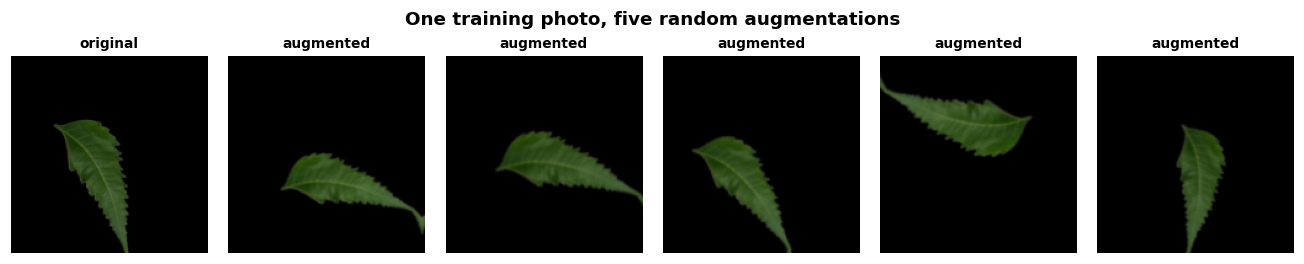

In [7]:
# =============================================================================
# AUGMENTATION (active during training only)
# =============================================================================
augment = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),   # a leaf has no "right way up"
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
], name="augmentation")

sample = next(iter(ds_tr))[0][:1]
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
axes[0].imshow(sample[0].numpy().astype("uint8")); axes[0].set_title("original", fontsize=9)
for ax in axes[1:]:
    ax.imshow(np.clip(augment(sample, training=True)[0].numpy(), 0, 255).astype("uint8"))
    ax.set_title("augmented", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.suptitle("One training photo, five random augmentations", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_augmentation_examples.png"))
plt.show()

## Step 4 — Build the model

In [8]:
# =============================================================================
# THE ARCHITECTURE
# =============================================================================
def residual_block(x, filters, stride, name):
    """Two 3x3 convolutions plus the skip connection: output = F(x) + x."""
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_bn1")(y)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_bn2")(y)
    # If the block halves the image or changes the channel count, the shortcut
    # no longer has the same shape as F(x). A 1x1 convolution reshapes it
    # (a "projection shortcut") so the two can be added.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False, name=f"{name}_proj")(shortcut)
        shortcut = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_proj_bn")(shortcut)
    y = layers.Add(name=f"{name}_add")([y, shortcut])           # the skip connection
    return layers.Activation("relu", name=f"{name}_out")(y)


def build_model(num_classes):
    """ResNet-18: stem, four stages of two residual blocks, global average, softmax."""
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="photo")
    x = augment(inp)                                   # training only
    x = layers.Rescaling(1.0 / 255, name="scale_0_1")(x)
    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, name="stem_conv")(x)
    x = layers.BatchNormalization(momentum=BN_MOMENTUM, name="stem_bn")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same", name="stem_pool")(x)
    for stage, filters in enumerate([64, 128, 256, 512], start=1):
        for block in (1, 2):
            stride = 2 if (stage > 1 and block == 1) else 1
            x = residual_block(x, filters, stride, name=f"s{stage}b{block}")
    x = layers.GlobalAveragePooling2D(name="global_avg")(x)
    x = layers.Dropout(0.4, name="dropout")(x)
    out = layers.Dense(num_classes, activation="softmax", name="plant")(x)
    return keras.Model(inp, out, name="resnet18")


model = build_model(NUM_CLASSES)
model.summary(line_length=100)
n_conv = sum(isinstance(l, layers.Conv2D) for l in model.layers)
n_add = sum(isinstance(l, layers.Add) for l in model.layers)
n_proj = sum(l.name.endswith("_proj") for l in model.layers)
print(f"Convolution layers: {n_conv}  (1 stem + 16 in blocks + {n_proj} projection shortcuts)")
print(f"Skip connections:   {n_add}")
print("Weighted layers counted in the name 'ResNet-18': 1 stem + 16 block convs + 1 output = 18")
N_PARAMS = int(model.count_params())
print(f"\nParameters: {N_PARAMS:,}   (about {N_PARAMS * 4 / 1e6:.2f} MB as float32, "
      f"{N_PARAMS / 1e6:.2f} MB after INT8 compression)")

Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ photo (InputLayer)          │ (None, 160, 160, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ augmentation (Sequential)   │ (None, 160, 160, 3)     │              0 │ photo[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ scale_0_1 (Rescaling)       │ (None, 160, 160, 3)     │              0 │ augmentation[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv (Conv2D)          │ (None, 80, 80, 64)      │          9,408 │ scale_0_1[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_bn                     │ (None, 80, 80, 64)      │            256 │ stem_conv[0][0]         │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_relu (Activation)      │ (None, 80, 80, 64)      │              0 │ stem_bn[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_pool (MaxPooling2D)    │ (None, 40, 40, 64)      │              0 │ stem_relu[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_conv1 (Conv2D)         │ (None, 40, 40, 64)      │         36,864 │ stem_pool[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_bn1                    │ (None, 40, 40, 64)      │            256 │ s1b1_conv1[0][0]        │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_relu1 (Activation)     │ (None, 40, 40, 64)      │              0 │ s1b1_bn1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_conv2 (Conv2D)         │ (None, 40, 40, 64)      │         36,864 │ s1b1_relu1[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_bn2                    │ (None, 40, 40, 64)      │            256 │ s1b1_conv2[0][0]        │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_add (Add)              │ (None, 40, 40, 64)      │              0 │ s1b1_bn2[0][0],         │
│                             │                         │                │ stem_pool[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b1_out (Activation)       │ (None, 40, 40, 64)      │              0 │ s1b1_add[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b2_conv1 (Conv2D)         │ (None, 40, 40, 64)      │         36,864 │ s1b1_out[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ s1b2_bn1                    │ (None, 40, 40, 64)      │            256 │ s1b2_conv1[0][0]        │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 11,189,190 (42.68 MB)

 Trainable params: 11,179,590 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

Convolution layers: 20  (1 stem + 16 in blocks + 3 projection shortcuts)
Skip connections:   8
Weighted layers counted in the name 'ResNet-18': 1 stem + 16 block convs + 1 output = 18

Parameters: 11,189,190   (about 44.76 MB as float32, 11.19 MB after INT8 compression)


### Reading the summary

The summary is long because every block is listed layer by layer. The layers to
look for:

- **`s1b1_conv1` … `s4b2_conv2`** — the 16 convolutions inside the 8 residual
  blocks (stage 1–4, block 1–2).
- **`..._add`** — the 8 skip connections, where F(x) and x are added together.
- **`..._proj`** — 1×1 projection shortcuts. They appear only at the first block
  of stages 2, 3 and 4, where the image halves and the filters double, so x
  must be reshaped before it can be added.
- **stem** — a large 7×7 convolution with stride 2, then max-pooling. It shrinks
  the photo from 160 to 40 quickly, so the expensive blocks work on small maps.

Compare the parameter count with the Simple CNN's 391,141. Most of ResNet-18's
weights sit in stage 4, where each 3×3 convolution maps 512 channels to 512.

## Step 5 — Train

- **Early stopping** watches validation accuracy. If it hasn't improved for
  10 epochs, training stops and the **best** weights are restored.
- **Learning-rate reduction** halves the step size when validation loss stalls,
  so the model can settle into a finer solution.

On a laptop CPU, expect roughly 1–3 minutes per epoch.

In [9]:
# =============================================================================
# TRAIN
# =============================================================================
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

ckpt_path = os.path.join(MODEL_DIR, f"{TAG}.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=PATIENCE,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                      min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", mode="max",
                                    save_best_only=True),
]

t0 = time.time()
history = model.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
train_seconds = time.time() - t0
h = history.history
epochs_run = len(h["loss"])
best_epoch = int(np.argmax(h["val_accuracy"])) + 1
print(f"\nTrained {epochs_run} epochs in {train_seconds / 60:.1f} min; best epoch = {best_epoch}")

Epoch 1/60


c:\Users\OKEDI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


58/58 - 128s - 2s/step - accuracy: 0.6046 - loss: 1.1787 - val_accuracy: 0.5360 - val_loss: 2.9576 - learning_rate: 0.0010
Epoch 2/60
58/58 - 115s - 2s/step - accuracy: 0.7395 - loss: 0.6937 - val_accuracy: 0.3716 - val_loss: 2.0622 - learning_rate: 0.0010
Epoch 3/60
58/58 - 117s - 2s/step - accuracy: 0.7733 - loss: 0.6403 - val_accuracy: 0.3581 - val_loss: 2.3925 - learning_rate: 0.0010
Epoch 4/60
58/58 - 122s - 2s/step - accuracy: 0.8247 - loss: 0.5115 - val_accuracy: 0.6959 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 5/60
58/58 - 108s - 2s/step - accuracy: 0.8394 - loss: 0.4089 - val_accuracy: 0.7410 - val_loss: 0.6298 - learning_rate: 0.0010
Epoch 6/60
58/58 - 117s - 2s/step - accuracy: 0.8318 - loss: 0.5109 - val_accuracy: 0.6239 - val_loss: 1.0351 - learning_rate: 0.0010
Epoch 7/60
58/58 - 120s - 2s/step - accuracy: 0.8367 - loss: 0.4123 - val_accuracy: 0.7815 - val_loss: 0.5688 - learning_rate: 0.0010
Epoch 8/60
58/58 - 109s - 2s/step - accuracy: 0.8378 - loss: 0.3808 - val

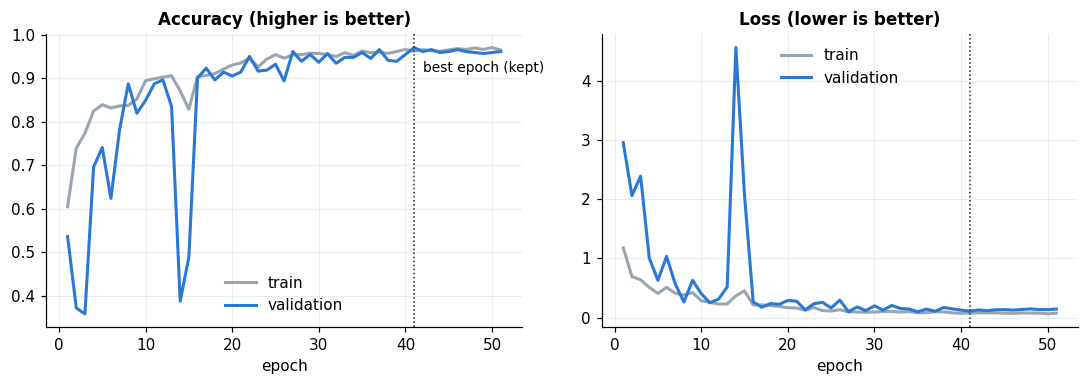

Train - validation accuracy gap at the kept epoch: -0.008


In [10]:
# =============================================================================
# FIGURE: TRAINING CURVES
# =============================================================================
ep = np.arange(1, epochs_run + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, k, title in [(axes[0], "accuracy", "Accuracy (higher is better)"),
                     (axes[1], "loss", "Loss (lower is better)")]:
    ax.plot(ep, h[k], color=MUTED, linewidth=2, label="train")
    ax.plot(ep, h[f"val_{k}"], color=MAIN, linewidth=2, label="validation")
    ax.axvline(best_epoch, color=INK, linewidth=1, linestyle=":")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(frameon=False)
axes[0].annotate("best epoch (kept)", (best_epoch, h["val_accuracy"][best_epoch - 1]),
                 xytext=(6, -16), textcoords="offset points", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_training_curves.png"))
plt.show()

gap = h["accuracy"][best_epoch - 1] - h["val_accuracy"][best_epoch - 1]
print(f"Train - validation accuracy gap at the kept epoch: {gap:+.3f}")
if gap > 0.10:
    print("A large gap means overfitting: the model memorised training leaves. Report it.")

### Reading the curves

If training accuracy keeps rising while validation accuracy flattens, the model
is **memorising** the training leaves instead of learning what each plant looks
like. That's overfitting. The dotted line marks the epoch we kept.

Early on, training accuracy can sit *below* validation. Augmentation makes
training photos harder than the untouched validation photos. That's normal.

## Step 6 — The test set, once

Everything above used training and validation photos only. This is the first
and only time the model sees the test photos. These are the numbers you report.

In [11]:
# =============================================================================
# TEST-SET EVALUATION
# =============================================================================
P_va = model.predict(ds_va, verbose=0)
P_te = model.predict(ds_te, verbose=0)
pred_te = P_te.argmax(1)

acc = accuracy_score(y_te, pred_te)
macro_f1 = f1_score(y_te, pred_te, average="macro")
top2 = top_k_accuracy_score(y_te, P_te, k=2, labels=np.arange(NUM_CLASSES))
roc = roc_auc_score(y_te, P_te, multi_class="ovr", average="macro")
prec, rec, f1s, sup = precision_recall_fscore_support(y_te, pred_te, labels=np.arange(NUM_CLASSES),
                                                     zero_division=0)

print(f"TEST SET ({len(y_te):,} photos)\n")
print(f"  Accuracy          {acc:.4f}")
print(f"  Macro F1          {macro_f1:.4f}   <- headline: treats every plant equally")
print(f"  Top-2 accuracy    {top2:.4f}   (right answer in the model's first two guesses)")
print(f"  Macro ROC-AUC     {roc:.4f}\n")
per_class = pd.DataFrame({"precision": prec, "recall": rec, "F1": f1s, "test photos": sup},
                         index=CLASSES)
per_class.round(3)

TEST SET (332 photos)

  Accuracy          0.9669
  Macro F1          0.9083   <- headline: treats every plant equally
  Top-2 accuracy    1.0000   (right answer in the model's first two guesses)
  Macro ROC-AUC     0.9994



,precision,recall,F1,test photos
1,0.992,1.000,0.996,123
aloe_vera_bg,0.667,1.000,0.800,2
moringa_bg,1.000,1.000,1.000,55
nim_2_bg,0.987,0.894,0.938,85
nim_bg,0.600,1.000,0.750,9
tulsi_bg,0.966,0.966,0.966,58


### How to read these numbers

- **Accuracy**: the share of test photos named correctly.
- **Macro F1**: F1 computed for each plant separately, then averaged, so a rare
  plant counts as much as a common one. This is the headline number for
  comparing the four models.
- **Per-plant recall**: of all the real neem photos, how many were called neem?
- **Per-plant precision**: of all the photos called neem, how many really were?
- **Top-2 accuracy**: was the right plant at least the model's second guess?
  A high top-2 with lower accuracy means the model is close, and usually torn
  between two look-alike species.

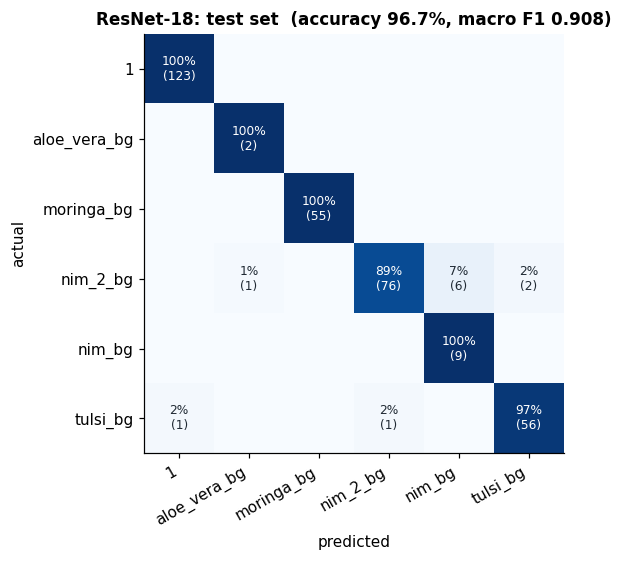

Most common mistake: nim_2_bg called nim_bg (6 photos)


In [12]:
# =============================================================================
# FIGURE: CONFUSION MATRIX (rows sum to 100%)
# =============================================================================
cm = confusion_matrix(y_te, pred_te, labels=np.arange(NUM_CLASSES))
cm_pct = cm / cm.sum(1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
ax.grid(False)
ax.set_xticks(range(NUM_CLASSES), CLASSES, rotation=30, ha="right")
ax.set_yticks(range(NUM_CLASSES), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j]:
            ax.text(j, i, f"{cm_pct[i, j]:.0f}%\n({cm[i, j]})", ha="center", va="center",
                    fontsize=8, color="white" if cm_pct[i, j] > 55 else INK)
ax.set_title(f"{MODEL_NAME}: test set  (accuracy {acc:.1%}, macro F1 {macro_f1:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_confusion.png"))
plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
if off.sum():
    i, j = np.unravel_index(off.argmax(), off.shape)
    print(f"Most common mistake: {CLASSES[i]} called {CLASSES[j]} ({off[i, j]} photos)")

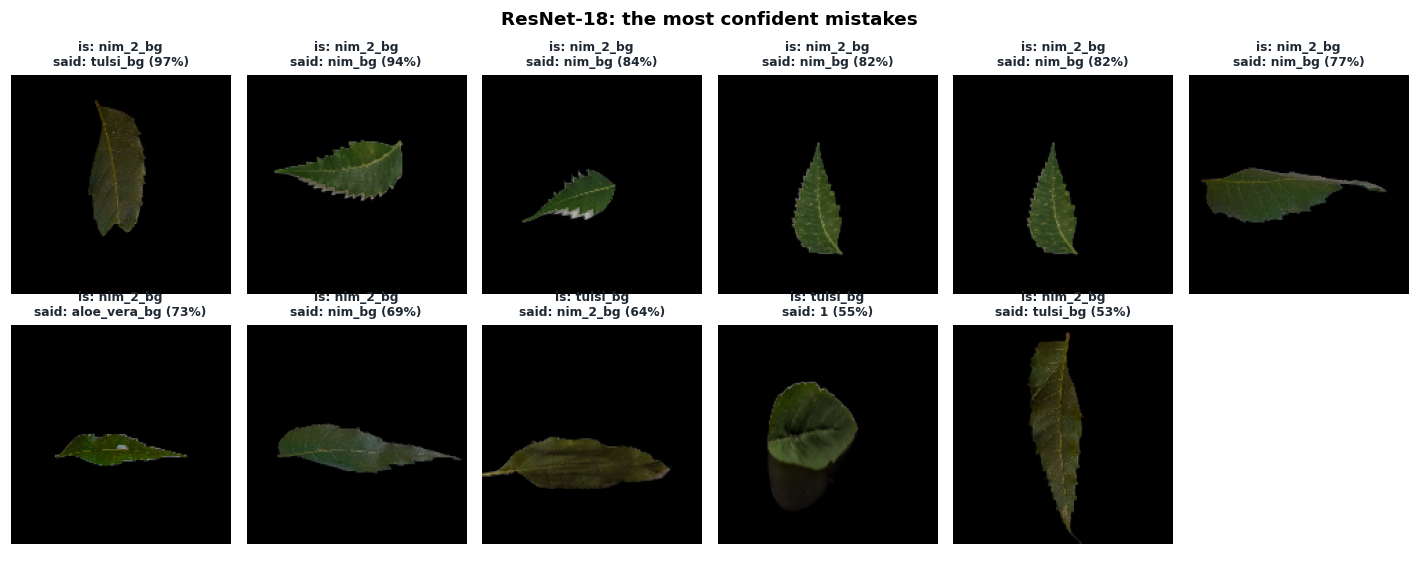

In [13]:
# =============================================================================
# FIGURE: WHAT DID IT GET WRONG?  (up to 12 misclassified test photos)
# =============================================================================
wrong = np.where(pred_te != y_te)[0]
if len(wrong) == 0:
    print("No test photo was misclassified.")
else:
    wrong = wrong[np.argsort(-P_te[wrong].max(1))][:12]    # most confident mistakes first
    cols = 6
    rows = int(np.ceil(len(wrong) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 2.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, i in zip(axes, wrong):
        img = tf.io.decode_image(tf.io.read_file(te_df.loc[i, "path"]), channels=3,
                                 expand_animations=False)
        ax.imshow(tf.image.resize(img, (IMG_SIZE, IMG_SIZE)).numpy().astype("uint8"))
        ax.set_title(f"is: {CLASSES[y_te[i]]}\nsaid: {CLASSES[pred_te[i]]} ({P_te[i].max():.0%})",
                     fontsize=8, color=INK)
    plt.suptitle(f"{MODEL_NAME}: the most confident mistakes", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{TAG}_mistakes.png"))
    plt.show()

### Use this gallery in the report

Look for a pattern. Are the mistakes blurry? Photographed against a busy
background? Young leaves that don't yet look like the adult plant? A named
pattern is a far stronger discussion point than "the model made errors".

## Step 7 — The reject option: "I'm not sure"

On the collar, a wrong answer is worse than no answer. A goat eating a leaf that
gets **mislabelled** as neem puts a false record into the heritage database.

So the model only names a plant when its top probability reaches a threshold
**θ** (theta). Below that, it says *"not sure"* and the photo is kept for a
person to check. θ is chosen on **validation**: the lowest value at which the
answered photos are at least **98%** correct. Then it's applied to test.

The trade-off is **coverage**: the share of photos the model is willing to answer.

theta = 0.73  (lowest value giving >= 98% on validation)
On TEST: answers 97.3% of photos, and is right on 98.1% of those.
         the other 2.7% are passed to a person to check.


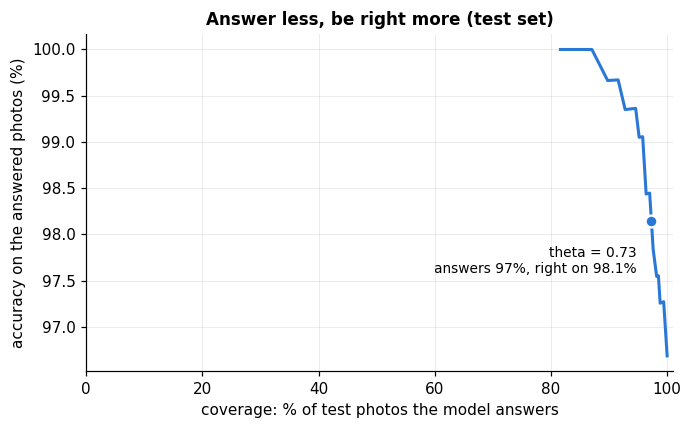

In [14]:
# =============================================================================
# REJECT THRESHOLD (chosen on validation) AND ITS EFFECT ON TEST
# =============================================================================
def coverage_curve(P, y, thetas):
    conf, pred = P.max(1), P.argmax(1)
    cov, accs = [], []
    for t in thetas:
        keep = conf >= t
        cov.append(keep.mean())
        accs.append((pred[keep] == y[keep]).mean() if keep.any() else np.nan)
    return np.array(cov), np.array(accs)


thetas = np.round(np.arange(0.20, 1.0, 0.01), 2)
cov_va, acc_va = coverage_curve(P_va, y_va, thetas)
ok = np.where((acc_va >= TARGET_ACCEPTED_ACCURACY) & (cov_va > 0))[0]
if len(ok):
    THETA = float(thetas[ok[0]])
    theta_note = f"lowest value giving >= {TARGET_ACCEPTED_ACCURACY:.0%} on validation"
else:
    # The target can't be reached. Take the most accurate theta that still
    # answers at least half of the validation photos.
    usable = np.where(cov_va >= 0.5)[0]
    THETA = float(thetas[usable[np.nanargmax(acc_va[usable])]])
    theta_note = (f"{TARGET_ACCEPTED_ACCURACY:.0%} was not reachable on validation; this is the most "
                  "accurate theta that still answers at least half the photos")

cov_te, acc_te = coverage_curve(P_te, y_te, thetas)
k = list(thetas).index(THETA)
reject = {"theta": THETA, "target_accuracy": TARGET_ACCEPTED_ACCURACY,
          "test_coverage": float(cov_te[k]),
          "test_accuracy_on_answered": (float(acc_te[k]) if cov_te[k] > 0 else None)}
reject["note"] = theta_note
print(f"theta = {THETA:.2f}  ({theta_note})")
if cov_te[k] > 0:
    print(f"On TEST: answers {cov_te[k]:.1%} of photos, and is right on {acc_te[k]:.1%} of those.")
else:
    print("On TEST: no photo reached theta, so the model answered none of them.")
print(f"         the other {1 - cov_te[k]:.1%} are passed to a person to check.")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(cov_te * 100, acc_te * 100, color=MAIN, linewidth=2)
ax.set_xlim(0, 101)
ax.scatter([cov_te[k] * 100], [acc_te[k] * 100], s=60, color=MAIN, edgecolor="white",
           linewidth=1.5, zorder=3)
ax.annotate(f"theta = {THETA:.2f}\nanswers {cov_te[k]:.0%}" + (f", right on {acc_te[k]:.1%}" if cov_te[k] > 0 else ""),
            (cov_te[k] * 100, acc_te[k] * 100), xytext=(-10, -34), textcoords="offset points",
            fontsize=9, ha="right")
ax.set_xlabel("coverage: % of test photos the model answers")
ax.set_ylabel("accuracy on the answered photos (%)")
ax.set_title("Answer less, be right more (test set)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_reject_option.png"))
plt.show()

## Step 8 — Could it run on the collar?

We record the number of weights, the saved file size, the size after INT8
compression (one byte per weight), and the time to classify **one** photo at a
time on this laptop.

In [15]:
# =============================================================================
# SIZE AND SPEED
# =============================================================================
model.save(ckpt_path)
size_mb = os.path.getsize(ckpt_path) / 1e6

infer = tf.function(lambda x: model(x, training=False))
one = next(iter(ds_te))[0][:1]
for _ in range(5):
    infer(one)                                   # warm-up
t0 = time.time()
for _ in range(50):
    infer(one)
ms_per_image = 1000 * (time.time() - t0) / 50

print(f"Weights:          {N_PARAMS:,}")
print(f"Saved file:       {size_mb:.2f} MB  ({ckpt_path})")
print(f"INT8 estimate:    {N_PARAMS / 1e6:.3f} MB")
print(f"Speed:            {ms_per_image:.1f} ms per photo, one at a time, on this laptop")

Weights:          11,189,190
Saved file:       134.51 MB  (plant_results\models\M2_2_ResNet18.keras)
INT8 estimate:    11.189 MB
Speed:            32.9 ms per photo, one at a time, on this laptop


In [16]:
# =============================================================================
# SAVE RESULTS  (the comparison notebook reads these)
# =============================================================================
results = {
    "model": MODEL_NAME,
    "tag": TAG,
    "family": "deep residual network",
    "image_size": IMG_SIZE,
    "split_id": SPLIT_ID,
    "classes": CLASSES,
    "epochs_run": epochs_run,
    "best_epoch": best_epoch,
    "train_val_gap": float(gap),
    "test": {"accuracy": float(acc), "macro_f1": float(macro_f1), "top2_accuracy": float(top2),
             "macro_roc_auc": float(roc),
             "per_class": {c: {"precision": float(p), "recall": float(r), "f1": float(f)}
                           for c, p, r, f in zip(CLASSES, prec, rec, f1s)},
             "confusion_matrix": cm.tolist()},
    "reject_option": reject,
    "parameters": N_PARAMS,
    "model_size_mb": round(size_mb, 3),
    "int8_estimate_mb": round(N_PARAMS / 1e6, 3),
    "ms_per_image": round(ms_per_image, 2),
    "train_seconds": round(train_seconds, 1),
    "test_photos": int(len(y_te)),
}
json.dump(results, open(os.path.join(RESULTS_DIR, f"{TAG}.json"), "w"), indent=2)

# Per-photo test probabilities, for the confidence intervals in the comparison.
np.savez_compressed(os.path.join(RESULTS_DIR, f"{TAG}_test_probs.npz"),
                    probs=P_te, y=y_te, groups=te_df["group"].values.astype(str),
                    classes=np.array(CLASSES))
print(f"Saved: {os.path.join(RESULTS_DIR, TAG + '.json')}")
print(f"Test accuracy {acc:.4f}   macro F1 {macro_f1:.4f}   "
      f"coverage at theta {reject['test_coverage']:.1%}")

Saved: plant_results\results\M2_2_ResNet18.json
Test accuracy 0.9669   macro F1 0.9083   coverage at theta 97.3%


## Scoreboard so far

Reads every plant-model results file in `plant_results/results/`, so the table
grows as you train the other three.

In [17]:
# =============================================================================
# SCOREBOARD: EVERY M2 MODEL TRAINED SO FAR
# =============================================================================
rows = []
for p in sorted(glob.glob(os.path.join(RESULTS_DIR, "M2_*.json"))):
    r = json.load(open(p))
    if "test" not in r:
        continue
    rows.append({"model": r["model"], "split ID": r.get("split_id"), "accuracy": r["test"]["accuracy"],
                 "macro F1": r["test"]["macro_f1"], "top-2": r["test"]["top2_accuracy"],
                 "coverage @theta": r["reject_option"]["test_coverage"],
                 "weights": r["parameters"], "INT8 MB": r["int8_estimate_mb"],
                 "ms/photo": r["ms_per_image"]})
pd.DataFrame(rows).set_index("model").round(4)

,split ID,accuracy,macro F1,top-2,coverage @theta,weights,INT8 MB,ms/photo
model,,,,,,,,
Simple CNN,2ee04fb978,0.9789,0.9260,1.0,1.0000,391398,0.391,9.40
ResNet-18,2ee04fb978,0.9669,0.9083,1.0,0.9729,11189190,11.189,32.87


---

## What to write in your report about this model

1. **Method.** Original photos only; near-identical shots grouped by perceptual
   hash and split 70/15/15 by group; 160 × 160 input;
   on-the-fly augmentation during training; the architecture above; class-weighted
   cross-entropy; Adam; early stopping on validation accuracy; trained from scratch.
2. **Result.** Test accuracy and macro F1, plus the per-plant table.
3. **Errors.** The most common confusion from the matrix, and the pattern you
   see in the mistakes gallery.
4. **Reject option.** θ, and the coverage and accuracy it gives on test.
5. **Deployability.** Weights, INT8 size and time per photo.

## Next

`M2_3_MobileNetV2.ipynb`, a network designed from the ground up for phones and microcontrollers.